# Final Project : NutriTrack Phase 3, RAG Nutrition Assistant

---

## NutriTrack Phase 3, RAG Nutrition Assistant (Generative AI)
**Introduction** <br>
The first two phases of NutriTrack analysed the data and predicted diabetes risk. Phase 3 adds a generative AI assistant that answers nutrition and diabetes questions in plain language, grounded in the project's own data.

The assistant follows the retrieval augmented generation pattern. It first retrieves the most relevant facts from a knowledge base built directly from the NutriTrack database, then passes those facts to a Groq hosted language model that writes a short, cited answer. Because the answer is tied to real data, the assistant stays accurate instead of inventing numbers. It also calculates the nutrition of a described meal by calling a Python tool, so the arithmetic is exact rather than guessed by the model.

## Problem Statement:

Giving Trustworthy Nutrition Answers Without Inventing Numbers <br>

A plain chatbot can produce confident but wrong nutrition figures, and a user has no way to tell. The NutriTrack database already holds trustworthy USDA food values and NHANES diabetes insights, so the sensible design is to ground every answer in that data and to cite it.

A useful assistant for this project must:

Answer nutrition and diabetes questions from the NutriTrack data, with citations. <br>
Give general nutrition guidance when the data does not cover the question, clearly labelled. <br>
Calculate the total nutrition of a described meal accurately rather than guessing. <br>
Never diagnose, and remind the user to see a professional for personal health. <br>

### Areas of Impact
**1. Personal Wellness and Nutrition** <br>
-- Answers everyday food and diet questions grounded in real nutrition data. <br>
-- Calculates a meal's nutrition so a user can understand what they ate. <br>
**2. Healthcare Awareness** <br>
-- Explains how factors like BMI and age relate to diabetes, from the survey data. <br>
-- Always defers to a professional for personal health decisions. <br>
**3. Data Science and Applied Machine Learning** <br>
-- Demonstrates retrieval augmented generation, grounding, and tool calling. <br>
-- Shows how a language model and deterministic Python code work together. <br>
**4. Responsible AI** <br>
-- Grounds answers in a known source and cites them to reduce made up facts. <br>
-- Separates language, which the model handles, from arithmetic, which Python handles.

## Import Libraries:
This section imports the project's RAG engine from `rag.py` and the libraries used to build the knowledge base, retrieve facts, and draw the workflow diagram.

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import rag
DB_PATH = PROJECT_ROOT / 'database' / 'nutritrack.db'

print('RAG engine loaded from rag.py')
print('Default Groq model:', rag.DEFAULT_MODEL)

RAG engine loaded from rag.py
Default Groq model: openai/gpt-oss-20b


---
## Step 1: Build the Knowledge Base

**Context.** Retrieval augmented generation needs a set of facts to retrieve from, so the first step turns the NutriTrack database into a small collection of short, plain text facts.

**What the knowledge base is.** The knowledge base is a list of documents, where each document is one short fact. **Every fact is read or computed from the real database, so nothing in it is invented.**

In plain terms, we build one fact per USDA food, a handful of NHANES insight facts computed live from the survey table, and a few reference facts including the Phase 2 model card. This is the trusted source the assistant is allowed to answer from.

In [2]:
corpus = rag.build_corpus(DB_PATH)

print('Total facts:', len(corpus))
sources = {}
for d in corpus:
    key = d['source'].split(':')[0]
    sources[key] = sources.get(key, 0) + 1
for k, v in sources.items():
    print(f'  {k:<26} {v}')

Total facts: 336
  USDA food                  328
  NHANES insight             5
  Reference                  2
  NutriTrack Phase 2 model card 1


In [3]:
# The NHANES insight facts are computed live from the survey table.
for d in corpus:
    if d['source'].startswith('NHANES'):
        print('-', d['text'], '\n')

- In the cleaned NHANES 2017-2018 sample of 9,254 respondents, about 10.0 percent report diabetes. The target is imbalanced, which is why the Phase 2 model is judged on precision, recall, and F1 rather than accuracy alone. 

- Diabetes prevalence rises steeply with age in the NHANES sample. By age group: Under 30: 0.6 percent; 30 to 44: 4.8 percent; 45 to 59: 14.9 percent; 60 and over: 28.5 percent. 

- Diabetes prevalence rises with body mass index in the NHANES sample. By BMI category: Underweight: 0.3 percent; Normal: 5.1 percent; Overweight: 13.2 percent; Obese: 19.1 percent. 

- Correlation of factors with the diabetes indicator in the NHANES sample (association, not causation): glucose: r = 0.56; age: r = 0.36; bmi: r = 0.23; physical_activity: r = -0.04. Glucose is the strongest signal, followed by age and BMI. 

- Fasting glucose is measured only on the fasting subsample, so it is missing for about 69 percent of NHANES respondents. NutriTrack uses glucose only to define the tra

**Interpretation.** The knowledge base holds 336 facts: 328 USDA food facts, 5 NHANES insight facts, and 3 reference facts. The NHANES numbers match the Phase 1 analysis exactly, for example about 10 percent diabetes prevalence and a glucose correlation near 0.56, which confirms the facts are read from the real data rather than made up.

---
## Step 2: Retrieval with TF IDF

**Context.** For each question the assistant must find the few facts that are actually relevant, out of hundreds, before the language model sees anything.

**What TF IDF retrieval is.** TF IDF stands for term frequency inverse document frequency. It turns each fact and the question into a vector that weights words by how distinctive they are, then ranks facts by cosine similarity to the question. **Cosine similarity measures the angle between two vectors, so a smaller angle means a closer match.**

In plain terms, the retriever scores every fact against the question and returns the closest few. For a few hundred short facts this is instant and needs no heavy vector database, which keeps the design simple and easy to explain.

In [4]:
retriever = rag.Retriever(corpus)

questions = [
    'How does BMI relate to diabetes?',
    'How much protein is in dried egg white?',
    'What features does the risk model use?',
]
for q in questions:
    print('Q:', q)
    for c in retriever.retrieve(q, k=3):
        print(f"   [{c['score']:.3f}] {c['source']}")
    print()

Q: How does BMI relate to diabetes?
   [0.272] NHANES insight: feature correlations with diabetes
   [0.179] NHANES insight: diabetes prevalence by BMI category
   [0.123] Reference: ADA fasting glucose thresholds

Q: How much protein is in dried egg white?
   [0.414] USDA food: Egg, white, dried
   [0.295] USDA food: Egg, white, raw, frozen, pasteurized
   [0.295] USDA food: Eggs, Grade A, Large, egg white

Q: What features does the risk model use?
   [0.242] Reference: ADA fasting glucose thresholds
   [0.213] NutriTrack Phase 2 model card
   [0.080] NHANES insight: overall diabetes prevalence



**Interpretation.** Each question pulls back sensible facts. A BMI question surfaces the NHANES correlation and prevalence facts, a protein question surfaces the matching egg foods, and a model question surfaces the Phase 2 model card. The scores are modest because the facts are short, but the ranking is what matters, and the right facts sit at the top.

---
## Step 3: Grounded Generation with Groq

**Context.** Once the relevant facts are retrieved, a language model turns them into a clear answer, but it must stay tied to those facts rather than its own memory.

**What grounded generation is.** Grounding means the model is instructed to answer only from the facts it is given, and to cite them. **A hybrid prompt goes one step further: it answers from the data when the data covers the question, and falls back to clearly labelled general knowledge when it does not.**

In plain terms, the retrieved facts are numbered and placed in a context block with the question, and a strict system prompt tells the model to use them, cite them, never diagnose, and add a disclaimer. The system prompt below is the exact one the assistant uses.

In [5]:
print('SYSTEM PROMPT:\n')
print(rag.SYSTEM_PROMPT)

SYSTEM PROMPT:

You are NutriTrack Assistant, a helpful nutrition and diabetes awareness assistant. The Context block below holds facts drawn from the NutriTrack data (USDA foods and the NHANES survey). Use the context as your primary source: when it answers the question, base your answer on it and cite the facts you use with their bracket numbers, for example [2]. When the context does not fully cover the question, you may answer from general, well established nutrition knowledge, and make clear that this part is general guidance rather than something from the NutriTrack data. When the user lists foods with amounts and asks for totals (calories, protein, and so on), call the calculate_meal tool instead of doing the arithmetic yourself. Estimate grams for counts and scoops, for example 5 almonds is about 6 grams, 1 scoop of protein powder is about 30 grams, 1 medium banana is about 118 grams, and 350 ml of milk is about 360 grams. Keep answers short and clear. You are not a doctor: nev

In [6]:
# Show the numbered context block that is sent to the model for one question.
contexts = retriever.retrieve('How does BMI relate to diabetes?', k=4)
print('CONTEXT BLOCK SENT TO THE MODEL:\n')
print(rag.build_context_block(contexts))

# Run a live grounded answer if a Groq key is set, otherwise show the
# retrieval only fallback so this cell always runs.
api_key = rag.get_api_key()
question = 'How does BMI relate to diabetes risk?'
ctx = retriever.retrieve(question, k=4)
if api_key:
    print('\nGROUNDED ANSWER:\n')
    print(rag.answer(question, ctx, api_key, db_path=DB_PATH)['text'])
else:
    print('\nNo Groq key set here, showing the retrieval only fallback:\n')
    print(rag.retrieval_only_answer(ctx))

CONTEXT BLOCK SENT TO THE MODEL:

[1] Correlation of factors with the diabetes indicator in the NHANES sample (association, not causation): glucose: r = 0.56; age: r = 0.36; bmi: r = 0.23; physical_activity: r = -0.04. Glucose is the strongest signal, followed by age and BMI.
[2] Diabetes prevalence rises with body mass index in the NHANES sample. By BMI category: Underweight: 0.3 percent; Normal: 5.1 percent; Overweight: 13.2 percent; Obese: 19.1 percent.
[3] American Diabetes Association fasting glucose cut points, used by NutriTrack to build its risk label: below 100 mg/dL is normal (Low risk), 100 to 125 mg/dL is prediabetes (Medium risk), and 126 mg/dL or above is in the diabetes range (High risk).
[4] NutriTrack Phase 2 model card. The model is a tuned Random Forest that predicts a three class diabetes risk (Low, Medium, High) from ten non glucose features: age, gender, BMI, physical activity, and daily diet (calories, protein, carbs, fat, fiber, sugar). On the held out test set 

**Interpretation.** With a key set, the model returns a short answer that cites the fact numbers it used and ends with a reminder to see a professional. Without a key, the same context is shown directly, so the notebook and the app both still work for a demo. Either way the numbers come from the NutriTrack data, not from the model's memory. The hybrid prompt means a question the data does not cover, such as a general daily sugar guideline, still gets a helpful answer that is clearly labelled as general guidance.

---
## Step 4: The Meal Calculator Tool

**Context.** A common request is to add up the nutrition of a whole meal, and language models are unreliable at chained arithmetic, so this must not be left to the model.

**What tool calling is.** Tool calling lets the model call a real function instead of computing an answer itself. **Here the model parses the meal into food and gram pairs, then calls a Python tool that looks each food up in the USDA table and sums the nutrition, so the totals are exact and traceable.**

In plain terms, the model handles the messy language, estimating that five almonds is about six grams, and Python handles the maths. The tool below is called directly with a sample meal to show the exact figures it returns.

In [7]:
meal = [
    {'food': 'almonds', 'grams': 6},
    {'food': 'cashews', 'grams': 8},
    {'food': 'oats',    'grams': 40},
    {'food': 'banana',  'grams': 118},
    {'food': 'milk',    'grams': 360},
]
result = rag.calculate_meal(meal, DB_PATH)

rows = [{'Ingredient': it['input'], 'Matched USDA food': it['matched'],
         'Grams': it['grams'], 'Calories': it['calories'],
         'Protein (g)': it['protein'], 'Carbs (g)': it['carbs']}
        for it in result['items']]
display(pd.DataFrame(rows))

print('TOTALS:', result['totals'])
if result['not_found']:
    print('Not in the USDA foundation foods:', result['not_found'])

,Ingredient,Matched USDA food,Grams,Calories,Protein (g),Carbs (g)
0,almonds,"Nuts, almonds, whole, raw",6.0,35.0,1.3,1.2
1,cashews,"Nuts, cashew nuts, raw",8.0,42.7,1.4,2.9
2,oats,"Oats, whole grain, steel cut",40.0,151.7,5.0,27.9
3,banana,"Bananas, overripe, raw",118.0,100.3,0.9,23.7
4,milk,"Milk, whole, 3.25% milkfat, with added vitamin D",360.0,216.0,11.8,16.8


TOTALS: {'calories': 545.7, 'protein': 20.4, 'carbs': 72.5, 'fat': 20.3, 'fiber': 2.9, 'sugar': 0.0, 'sodium': 137.3}


**Interpretation.** Every ingredient is matched to a real USDA food, scaled to the grams eaten, and summed in Python. The matched food column shows which item was used, so the result is transparent, and any food not in the 328 USDA foundation foods, such as a branded protein powder, is reported rather than silently ignored. This is the key design choice that keeps the numbers trustworthy: the model reads the meal, but Python does the arithmetic.

---
## Step 5: Streamlit Integration

**Context.** The engine is only useful inside the app, so the final step confirms it is wired into the NutriTrack Streamlit application as a chat page.

**What the integration does.** The app imports `rag.py` and adds an AI Nutrition Assistant page with a chat box. **For each question it retrieves facts, calls Groq, shows the sources used under the answer, and calls the meal calculator when the user describes a meal.** If no key is present it falls back to retrieval only, so the page always works.

In [8]:
app_src = (PROJECT_ROOT / 'app.py').read_text(encoding='utf-8')
for check in ['import rag', 'def page_ai_assistant', 'AI Nutrition Assistant',
              'render_meal_calculation']:
    print(('found   ' if check in app_src else 'MISSING ') + check)

found   import rag
found   def page_ai_assistant
found   AI Nutrition Assistant
found   render_meal_calculation


**Interpretation.** The checks confirm the module import, the assistant page, the navigation entry, and the meal calculation display are all present in the app, so the Phase 3 engine is fully connected to the user interface.

---
## RAG Workflow Diagram
The diagram below summarises how a question flows through the assistant, from retrieval to a grounded, cited answer.

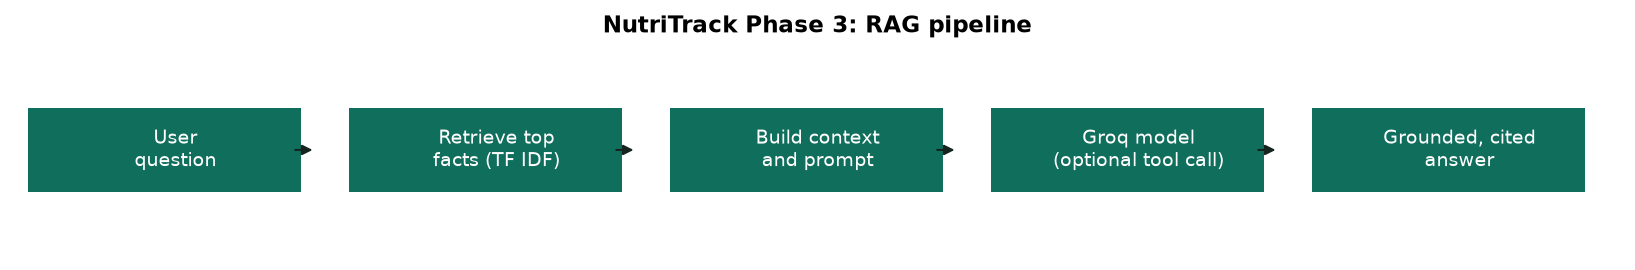

In [9]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(11, 1.9), dpi=150)
ax.axis('off')
steps = ['User\nquestion', 'Retrieve top\nfacts (TF IDF)', 'Build context\nand prompt',
         'Groq model\n(optional tool call)', 'Grounded, cited\nanswer']
n = len(steps)
for i, s in enumerate(steps):
    x = i / n
    ax.add_patch(plt.Rectangle((x + 0.008, 0.3), 1 / n - 0.03, 0.4, color='#0f6e5c', ec='none'))
    ax.text(x + (1 / n) / 2, 0.5, s, ha='center', va='center', color='white', fontsize=9)
    if i < n - 1:
        ax.annotate('', xy=(x + 1 / n - 0.012, 0.5), xytext=(x + 1 / n - 0.028, 0.5),
                    arrowprops=dict(arrowstyle='-|>', color='#16241f'))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('NutriTrack Phase 3: RAG pipeline', fontsize=11, weight='bold')
plt.tight_layout(); plt.show()

---
## Conclusion

**Summary.** This notebook delivered the Phase 3 generative AI stage of NutriTrack. It built a knowledge base of 336 facts directly from the database, retrieved the most relevant facts with TF IDF, generated grounded and cited answers with a Groq hosted model under a hybrid prompt, and added a meal calculator tool where Python does the arithmetic. It also confirmed the engine is wired into the Streamlit app.

**What makes it trustworthy.** Two design choices carry the project. First, every answer is grounded in the NutriTrack data and cites it, with a clearly labelled general fallback only when the data does not cover the question, so the assistant rarely invents facts. Second, the language model never does the meal arithmetic; it only parses the meal, and a Python tool computes the totals from the USDA table, so the numbers are exact.

**Design decisions.** TF IDF was chosen over a heavy vector database because the corpus is small, which keeps the system simple and easy to explain. The default Groq model is a small, fast, free tier model, and it can be swapped in one line. The assistant degrades gracefully to retrieval only when no key is present, so it is always demonstrable.

**Limitations.** The gram estimates for counted foods come from the model, so portions are approximate while the per 100 gram nutrition and the summing are exact. Food matching is limited to the 328 USDA foundation foods, so branded items may be missing. The assistant is for education and awareness and does not diagnose or replace medical care.

**Next steps.** Natural extensions include swapping the retriever for sentence embeddings if the knowledge base grows, persisting the chat history per user, and expanding the food table so the calculator covers more branded items.